In [1]:
from scipy.io import netcdf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import datetime as dt
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import pandas as pd
import glob
import copy
import pickle
import matplotlib.path as mpath
from netCDF4 import Dataset

#%% 01 read the data
# time management
Datestamp = pd.date_range(start="1979-01-01", end="2021-12-31")
Date0 = pd.DataFrame({'date': pd.to_datetime(Datestamp)})
nday = len(Date0)
Month = Date0['date'].dt.month
Year = Date0['date'].dt.year
Day = Date0['date'].dt.day
Datelist = list(Date0)
# BAM dates
feb_29_ind = Date0[(Month == 2) & (Day == 29)].index
# Remove February 29 from the Date DataFrame
print(Date0.shape, flush=True)
BAMDate = Date0
print(BAMDate.shape, flush=True)



(15706, 1)
(15706, 1)


(15706,)
10286
10376
2007-03-01 00:00:00
2007-05-30 00:00:00


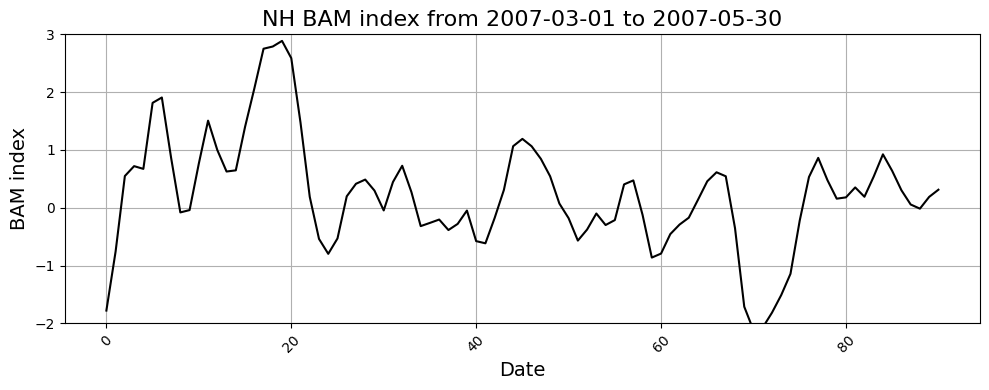

BAM_low_days: [np.int64(24), np.int64(80), np.int64(95), np.int64(105), np.int64(125), np.int64(156), np.int64(193), np.int64(217), np.int64(270), np.int64(312), np.int64(338), np.int64(365), np.int64(365), np.int64(393), np.int64(411), np.int64(463), np.int64(504), np.int64(542), np.int64(589), np.int64(610), np.int64(633), np.int64(677), np.int64(706), np.int64(740), np.int64(756), np.int64(780), np.int64(802), np.int64(844), np.int64(888), np.int64(906), np.int64(954), np.int64(974), np.int64(998), np.int64(1032), np.int64(1054), np.int64(1054), np.int64(1123), np.int64(1143), np.int64(1166), np.int64(1172), np.int64(1240), np.int64(1285), np.int64(1303), np.int64(1347), np.int64(1347), np.int64(1370), np.int64(1400), np.int64(1400), np.int64(1439), np.int64(1450), np.int64(1479), np.int64(1512), np.int64(1557), np.int64(1557), np.int64(1610), np.int64(1612), np.int64(1636), np.int64(1673), np.int64(1688), np.int64(1710), np.int64(1720), np.int64(1769), np.int64(1801), np.int64(1806

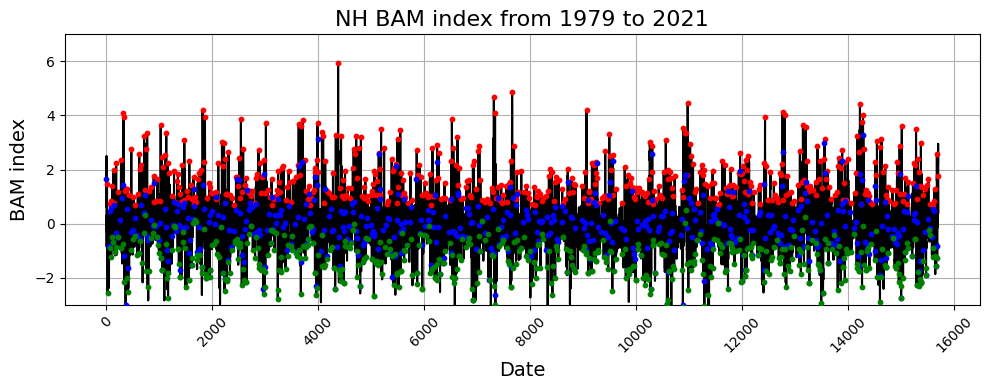

(15706,)
10286
10376
2007-03-01 00:00:00
2007-05-30 00:00:00


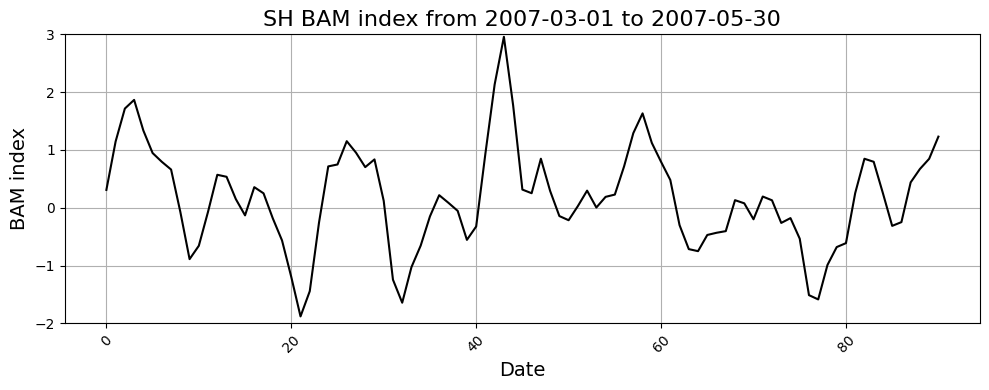

BAM_low_days: [np.int64(32), np.int64(65), np.int64(99), np.int64(130), np.int64(158), np.int64(200), np.int64(331), np.int64(359), np.int64(364), np.int64(400), np.int64(415), np.int64(448), np.int64(482), np.int64(500), np.int64(525), np.int64(538), np.int64(551), np.int64(551), np.int64(620), np.int64(651), np.int64(679), np.int64(710), np.int64(759), np.int64(777), np.int64(801), np.int64(801), np.int64(825), np.int64(851), np.int64(880), np.int64(912), np.int64(957), np.int64(996), np.int64(1040), np.int64(1060), np.int64(1128), np.int64(1134), np.int64(1225), np.int64(1274), np.int64(1284), np.int64(1284), np.int64(1334), np.int64(1363), np.int64(1381), np.int64(1405), np.int64(1424), np.int64(1450), np.int64(1481), np.int64(1513), np.int64(1529), np.int64(1529), np.int64(1563), np.int64(1588), np.int64(1588), np.int64(1603), np.int64(1641), np.int64(1655), np.int64(1667), np.int64(1686), np.int64(1718), np.int64(1742), np.int64(1824), np.int64(1858), np.int64(1874), np.int64(190

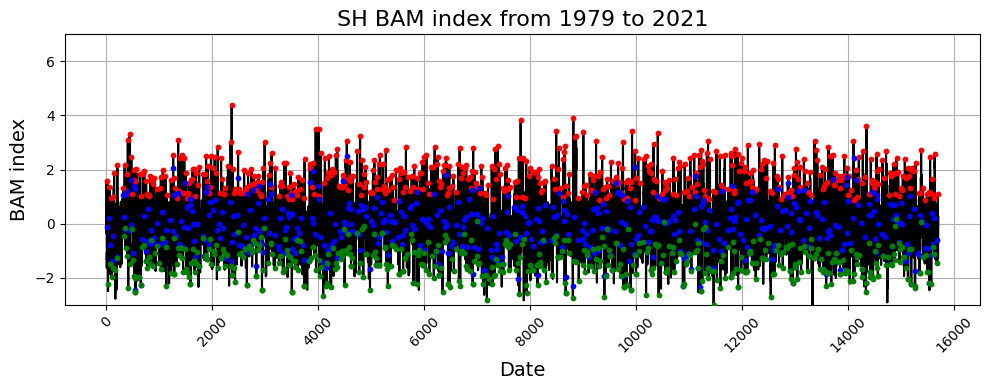

In [4]:
for k in ['NH', 'SH']:
    
    # read the BAM index
    BI = np.load(f'/scratch/bell/hu1029/LGHW/{k}_BAM_index_total_with_leap.npy')                             ### This is full BAM index from 1979 to 2021, 15695 in total, no leap years ###
    print(BI.shape, flush=True)

    # find the index of 2007-03-01 and 2007-05-30 
    stday = BAMDate[BAMDate['date']=='2007-03-01'].index[0]
    edday = BAMDate[BAMDate['date']=='2007-05-30'].index[0]
    print(stday, flush=True)
    print(edday, flush=True)
    print(BAMDate['date'][stday], flush=True)
    print(BAMDate['date'][edday], flush=True)

    # plot the BAM index during this period
    plt.figure(figsize=(10,4))
    plt.plot(np.arange(len(BI[stday:edday+1])), BI[stday:edday+1], color='k')
    plt.title(f'{k} BAM index from 2007-03-01 to 2007-05-30', fontsize=16)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('BAM index', fontsize=14)
    plt.ylim(-2, 3)
    plt.grid()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # plot the whole BAM index and the peak timepoint
    with open(f'/scratch/bell/hu1029/LGHW/{k}_BAM_event_peak_list.pkl', 'rb') as f:
        BAM_event_all = pickle.load(f)
    with open(f'/scratch/bell/hu1029/LGHW/{k}_BAM_event_low_list.pkl', 'rb') as f:
        BAM_event_low = pickle.load(f)

    BAM_low_days = []
    for idx in BAM_event_all:
        move = 12
        day_st = idx - move
        day_ed = idx + move + 1
        if day_st>=0 and day_ed<=len(Date0):
            # find the 3 lowest values and locations within the 25-day period
            # save the global index of the three lowest days as BAM_low_days
            window = BI[day_st:day_ed]
            lowest_indices = [np.argmin(window)]  # index of the single lowest value
            for li in lowest_indices:
                BAM_low_days.append(day_st + li)
    print('BAM_low_days:', sorted(BAM_low_days))
    BAM_low_days = np.array(sorted(BAM_low_days))


    plt.figure(figsize=(10,4))
    plt.plot(np.arange(len(BI)), BI, color='k')
    plt.scatter(BAM_event_all, BI[BAM_event_all], color='r', s=10, zorder=3)
    plt.scatter(BAM_event_low, BI[BAM_event_low], color='blue', s=10, zorder=3)
    plt.scatter(BAM_low_days, BI[BAM_low_days], color='green', s=10, zorder=3)
    plt.title(f'{k} BAM index from 1979 to 2021', fontsize=16)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('BAM index', fontsize=14)
    plt.ylim(-3, 7)
    plt.grid()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
